In [2]:
import rioxarray
import numpy as np
import importlib
import matplotlib.pyplot as plt

In [32]:
ndvi_data = rioxarray.open_rasterio('../input/cut_files/ndvi_cut_ex.tif')
vh_data = rioxarray.open_rasterio('../input/cut_files/vh_cut_ex.tif')
import rioxarray

input_path = "../input/cut_files/ST_Lua3v_cut.tif"
mask_data = rioxarray.open_rasterio(input_path)
# mask_data

In [3]:
ndvi_data

<xarray.DataArray (band: 13, y: 8874, x: 9902)> Size: 5GB
[1142314524 values with dtype=float32]
Coordinates:
  * band         (band) int64 104B 1 2 3 4 5 6 7 8 9 10 11 12 13
  * x            (x) float64 79kB 5.548e+05 5.548e+05 ... 6.538e+05 6.538e+05
  * y            (y) float64 71kB 1.106e+06 1.106e+06 ... 1.017e+06 1.017e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      NDVI

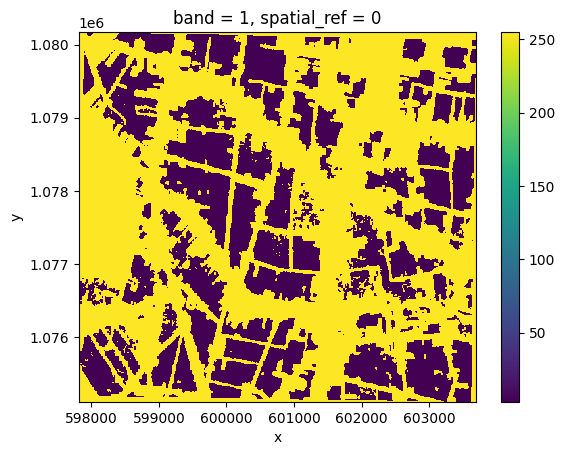

In [33]:
mask_data.plot()
plt.show()



In [ ]:
plt.imshow(ndvi_data[5], cmap='viridis')  # Display Band 10
plt.colorbar()  # Show the scale
plt.show()

In [34]:
import xarray as xr
import numpy as np

# Assuming 'data' is your xarray.DataArray
mask = mask_data != 255  # Boolean mask where values are not 255

# Stack x and y dimensions into a single index
data_stacked = mask_data.stack(points=("y", "x"))

# Apply the mask and drop NaN values
filtered = data_stacked.where(data_stacked != 255, drop=True)

# Extract x and y coordinates
x_indices = filtered.coords["x"].values
y_indices = filtered.coords["y"].values

# Stack into a (N, 2) NumPy array
xy_valid = np.column_stack((x_indices, y_indices))

print(xy_valid)  # Print or use the filtered coordinates

[[ 597932.754  1080165.3978]
 [ 597942.754  1080165.3978]
 [ 597952.754  1080165.3978]
 ...
 [ 603592.754  1075125.3978]
 [ 603602.754  1075125.3978]
 [ 603612.754  1075125.3978]]


In [6]:
ndvi_data

<xarray.DataArray (band: 13, y: 505, x: 587)> Size: 15MB
[3853655 values with dtype=float32]
Coordinates:
  * band         (band) int64 104B 1 2 3 4 5 6 7 8 9 10 11 12 13
  * x            (x) float64 5kB 5.978e+05 5.978e+05 ... 6.037e+05 6.037e+05
  * y            (y) float64 4kB 1.08e+06 1.08e+06 ... 1.075e+06 1.075e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:             Area
    STATISTICS_MAXIMUM:        0.96708613634109
    STATISTICS_MEAN:           0.48450134637311
    STATISTICS_MINIMUM:        -0.18222789466381
    STATISTICS_STDDEV:         0.28635324356944
    STATISTICS_VALID_PERCENT:  18.62
    scale_factor:              1.0
    add_offset:                0.0
    long_name:                 NDVI

In [6]:
vh_data

<xarray.DataArray (band: 13, y: 7680, x: 8687)> Size: 7GB
[867310080 values with dtype=float64]
Coordinates:
  * band         (band) int64 104B 1 2 3 4 5 6 7 8 9 10 11 12 13
  * x            (x) float64 69kB 5.597e+05 5.597e+05 ... 6.465e+05 6.465e+05
  * y            (y) float64 61kB 1.099e+06 1.099e+06 ... 1.022e+06 1.022e+06
    spatial_ref  int64 8B 0
Attributes:
    TIFFTAG_XRESOLUTION:  1
    TIFFTAG_YRESOLUTION:  1
    AREA_OR_POINT:        Area
    scale_factor:         1.0
    add_offset:           0.0

In [35]:
import xarray as xr
import numpy as np
from scipy.spatial import cKDTree

# Tạo DataArray đầu ra với NaN
ndvi_copy = xr.full_like(ndvi_data, fill_value=np.nan)

# Lưới toạ độ NDVI
x_vals = ndvi_data.coords["x"].values
y_vals = ndvi_data.coords["y"].values
xx, yy = np.meshgrid(x_vals, y_vals)

# KDTree từ grid NDVI
tree = cKDTree(np.column_stack([xx.ravel(), yy.ravel()]))

# Lặp qua từng band
for band in ndvi_data.band:
    print(f"Đang xử lý band {band.values}...")

    # NDVI của band hiện tại
    band_data = ndvi_data.sel(band=band)

    # Tìm pixel gần nhất với toàn bộ xy_valid
    _, indices = tree.query(xy_valid)

    # Chuyển index về (y, x)
    y_idx, x_idx = np.unravel_index(indices, xx.shape)

    # Lấy giá trị NDVI tại vị trí đó
    ndvi_values = band_data.values[y_idx, x_idx]

    # Tạo mảng mask với toàn NaN
    band_result = np.full_like(band_data.values, -2., dtype=np.float32)

    # Gán giá trị vào vị trí tương ứng
    band_result[y_idx, x_idx] = ndvi_values

    # Gán vào kết quả tổng
    ndvi_copy.loc[dict(band=band)] = band_result


Đang xử lý band 1...
Đang xử lý band 2...
Đang xử lý band 3...
Đang xử lý band 4...
Đang xử lý band 5...
Đang xử lý band 6...
Đang xử lý band 7...
Đang xử lý band 8...
Đang xử lý band 9...
Đang xử lý band 10...
Đang xử lý band 11...
Đang xử lý band 12...
Đang xử lý band 13...


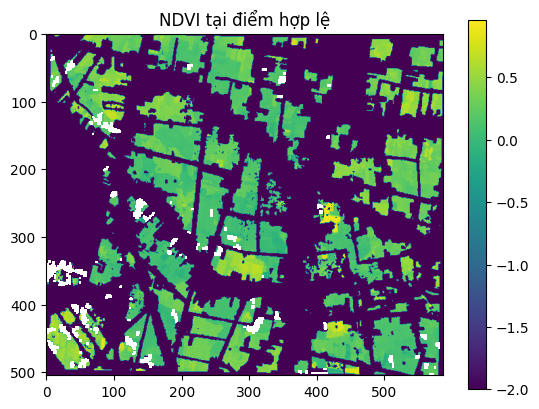

In [36]:
import matplotlib.pyplot as plt
# plt.imshow(result[1], cmap='RdYlGn')
# plt.imshow(result[2], cmap='coolwarm')
# plt.imshow(result[1], cmap='cividis')
plt.imshow(ndvi_copy[3], cmap='viridis')
plt.colorbar()
plt.title("NDVI tại điểm hợp lệ")
plt.show()


In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq
import fourierParam as params
# bias =  0.6699999999998791
bias = params.lua3v_bias
scales = params.lua3v_scale
# scales = [0.01696331, 0.05958546, 0.11391122, 0.13417442, 0.04152851,
#        0.04100452, 0.04283185, 0.04283185, 0.04100452, 0.04152851,
#        0.13417442, 0.11391122, 0.05958546]

In [10]:
def fourierCal(vh):
    ndvi_preds = []
    fft_vh = fft(vh)
    intercep = fft_vh*scales
    res = np.real(ifft(intercep)) + bias
    ndvi_preds.append(res)
    return ndvi_preds

    

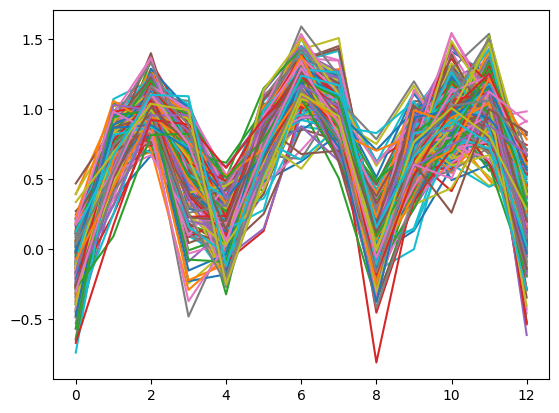

In [38]:
idx = 100
months = np.arange(13)
ndvi_act = []
ndvi_preds = []
for idx in range(0, 200):
    vh_test = vh_data.sel(x=xy_valid[idx][0], y=xy_valid[idx][1], method="nearest")
    ndvi_test = ndvi_data.sel(x=xy_valid[idx][0], y=xy_valid[idx][1], method="nearest")
    vh_test = np.array(vh_test)
    ndvi_res = fourierCal(vh_test)
    ndvi_act.append(ndvi_test.values)
    ndvi_preds.append(ndvi_res)
    # print(ndvi_test.values)
    # print(ndvi_res)
    plt.plot(months, np.squeeze(ndvi_res))
plt.show()
ndvi_preds = np.squeeze(ndvi_preds)

In [ ]:
# # Bước 1: Tìm tọa độ gần nhất có trong tập dữ liệu
# nearest_point = ndvi_copy.sel(x=xy_valid[0][0], y=xy_valid[0][1], method="nearest")
# nearest_x = float(nearest_point['x'].values)
# nearest_y = float(nearest_point['y'].values)

# # Bước 2: Gán giá trị vào đúng tọa độ gần nhất
# ndvi_copy.loc[dict(x=nearest_x, y=nearest_y)] = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

# # Kiểm tra lại
# print(ndvi_copy.sel(x=xy_valid[0][0], y=xy_valid[0][1], method="nearest"))


In [39]:
for idx in xy_valid:
    vh_val = vh_data.sel(x=idx[0], y=idx[1], method="nearest")
    vh_val = np.array(vh_val)
    ndvi_predict = np.squeeze(fourierCal(vh_val))
    # Bước 1: Tìm tọa độ gần nhất có trong tập dữ liệu
    nearest_point = ndvi_copy.sel(x=idx[0], y=idx[1], method="nearest")
    nearest_x = float(nearest_point['x'].values)
    nearest_y = float(nearest_point['y'].values)
    # Bước 2: Gán giá trị vào đúng tọa độ gần nhất
    # print("values before filling")
    # print(ndvi_copy.loc[dict(x=nearest_x, y=nearest_y)])
    ndvi_copy.loc[dict(x=nearest_x, y=nearest_y)] = ndvi_predict
    # print("values after  filling")
    # print(ndvi_copy.loc[dict(x=nearest_x, y=nearest_y)])
    # print("@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@")



In [40]:
import numpy as np
import xarray as xr

alpha = 0.3

def custom_clip_ndvi(ndvi: xr.DataArray) -> xr.DataArray:
    ndvi_corrected = ndvi.copy()
    
    mask_high = ndvi_corrected > 1
    ndvi_corrected = xr.where(mask_high, 1 + alpha * np.log10(ndvi_corrected - 1 + 1e-6), ndvi_corrected)
    
    mask_low = ndvi_corrected < -1
    ndvi_corrected = xr.where(mask_low, -1 - alpha * np.log10(-ndvi_corrected - 1 + 1e-6), ndvi_corrected)
    
    return ndvi_corrected


In [41]:
clipped_ndvi = custom_clip_ndvi(ndvi_copy)

d:\miniconda3\envs\remote-sensing\lib\site-packages\xarray\core\computation.py:821: RuntimeWarning: invalid value encountered in log10
  result_data = func(*input_data)
d:\miniconda3\envs\remote-sensing\lib\site-packages\xarray\core\computation.py:821: RuntimeWarning: invalid value encountered in log10
  result_data = func(*input_data)


In [42]:
clipped_ndvi.values.max()

np.float32(1.0)

In [43]:
import xarray as xr
import rioxarray

# Nếu DataArray có thông tin không gian (CRS, transform), thiết lập nó
clipped_ndvi.rio.set_spatial_dims(x_dim='x', y_dim='y', inplace=True)
clipped_ndvi.rio.write_crs("EPSG:32648", inplace=True)  # Ví dụ: thiết lập CRS là WGS84

# Xuất DataArray thành file TIFF
output_path = "../output/fourier/lua3v_pred.tif"
clipped_ndvi.rio.to_raster(output_path)

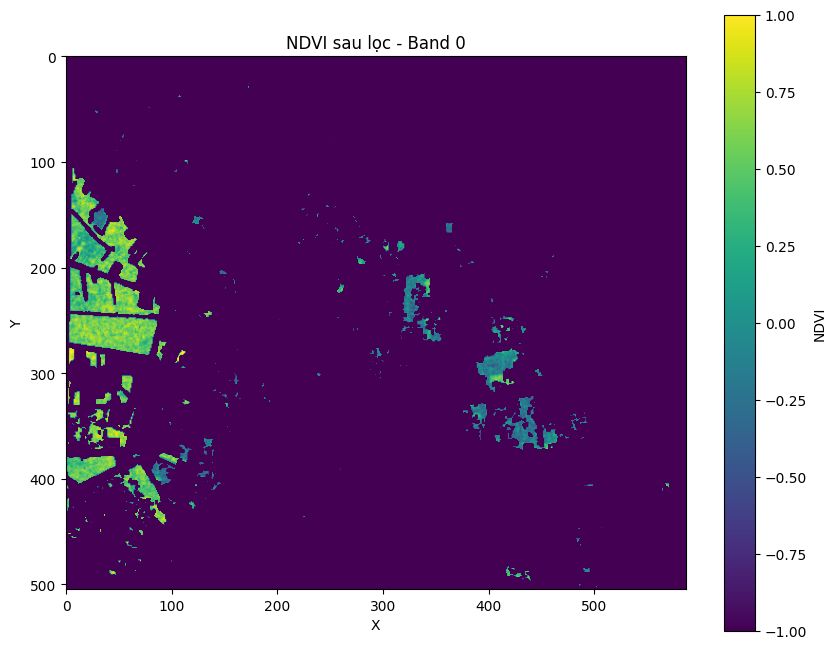

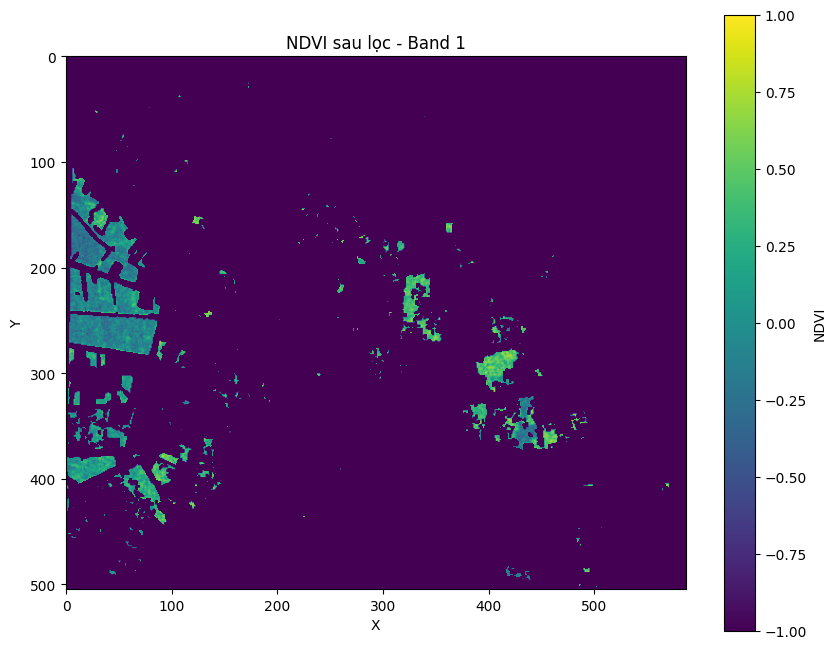

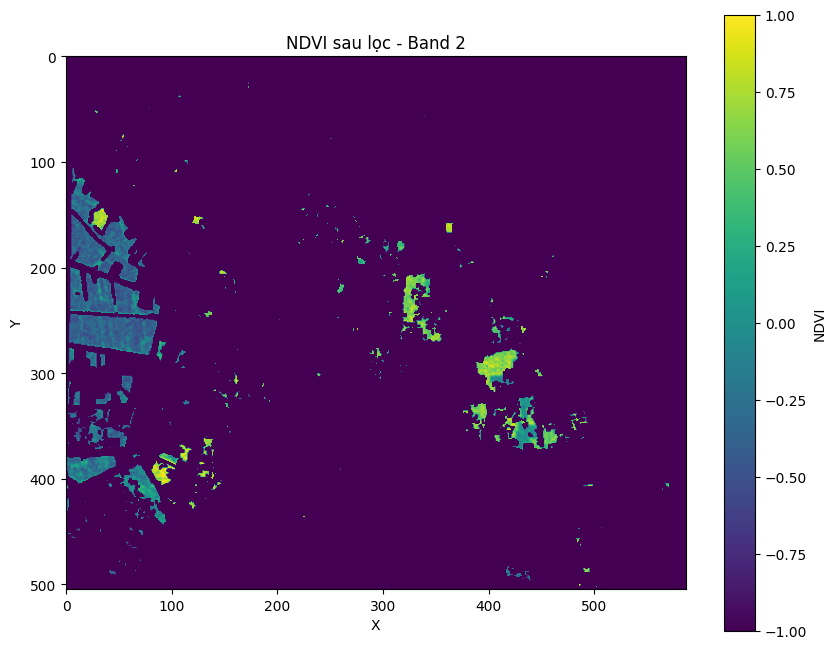

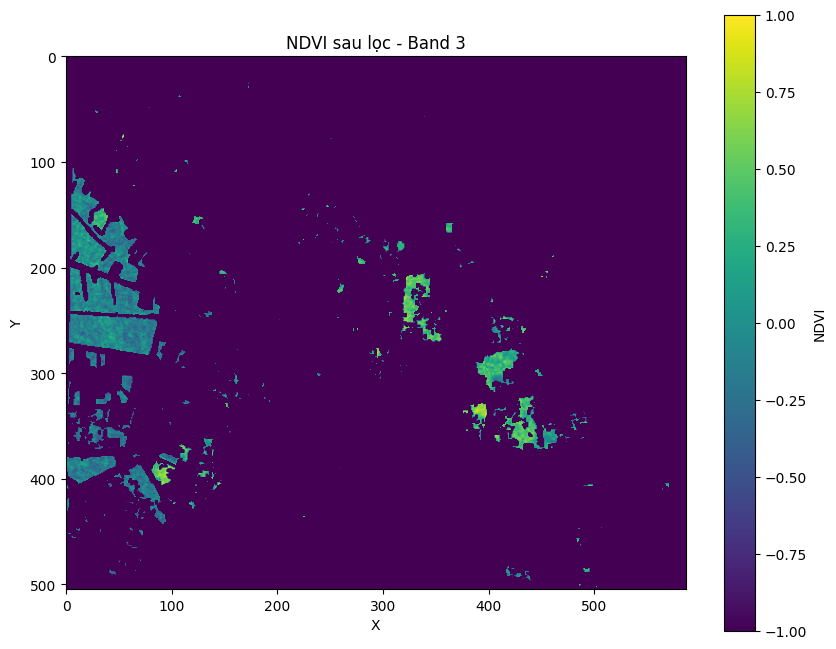

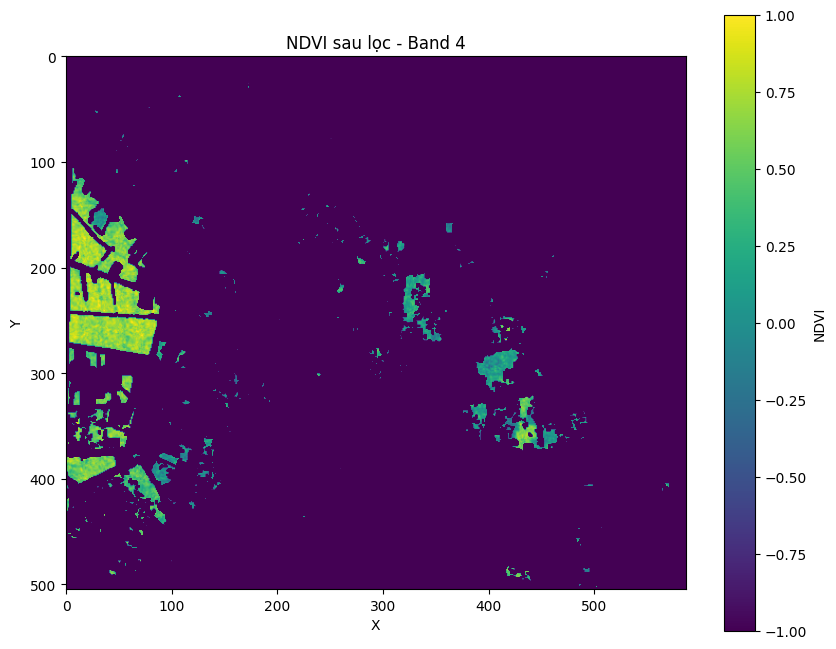

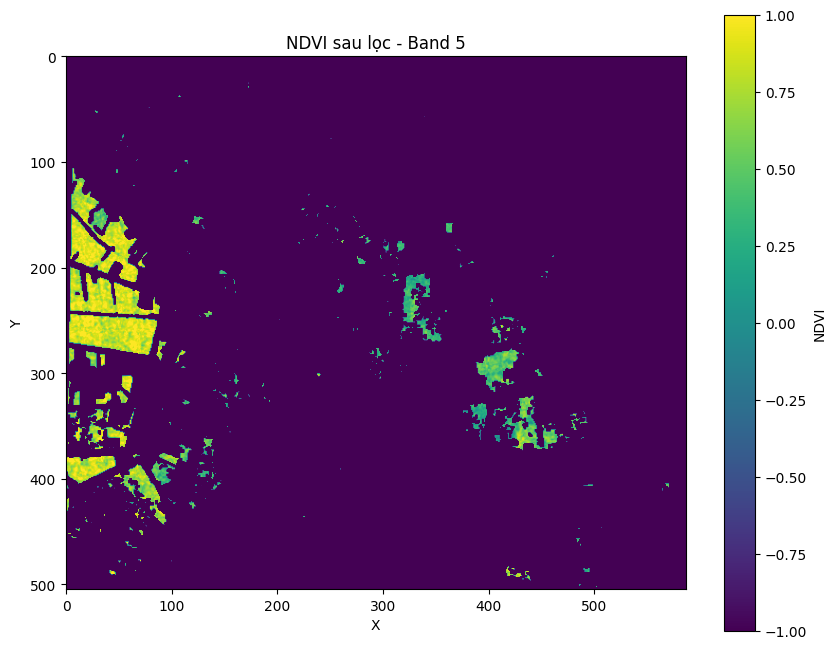

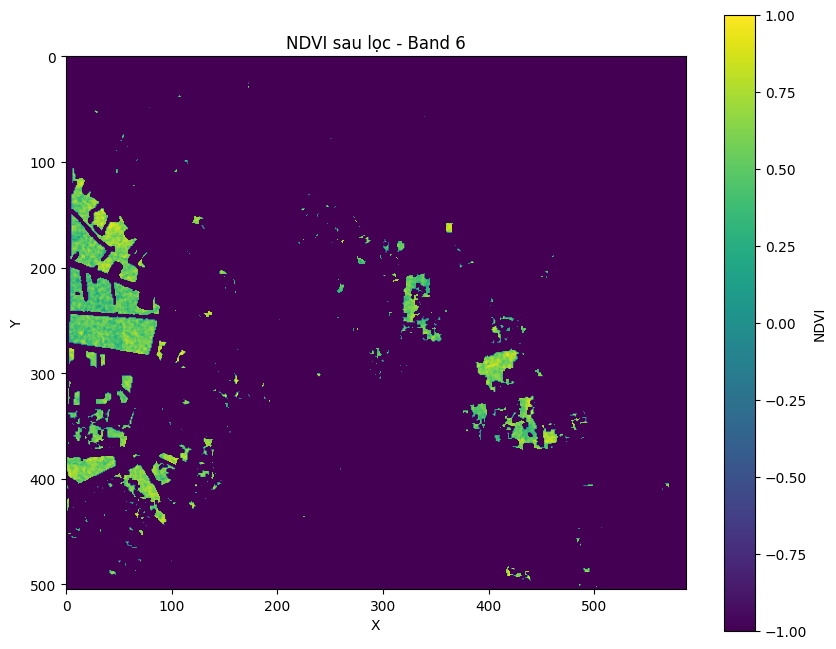

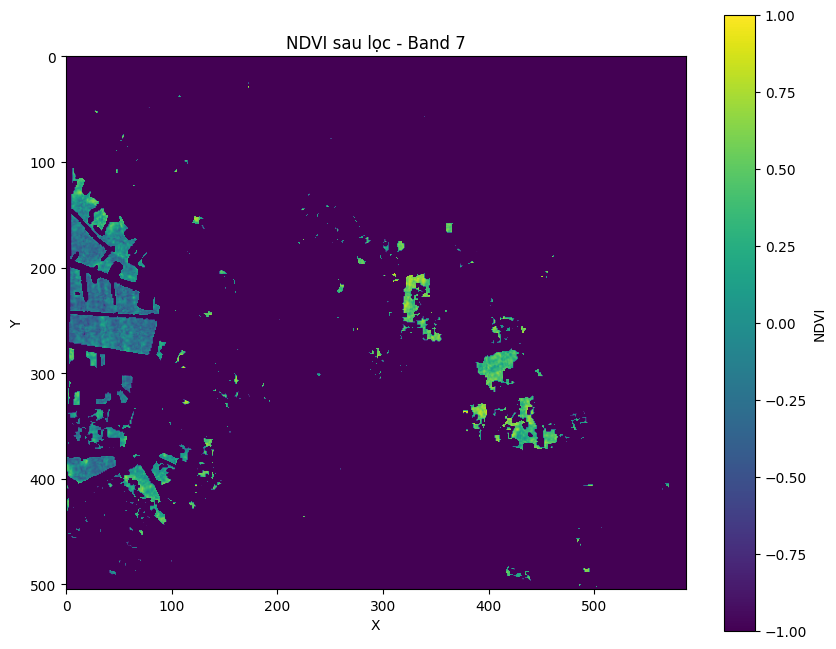

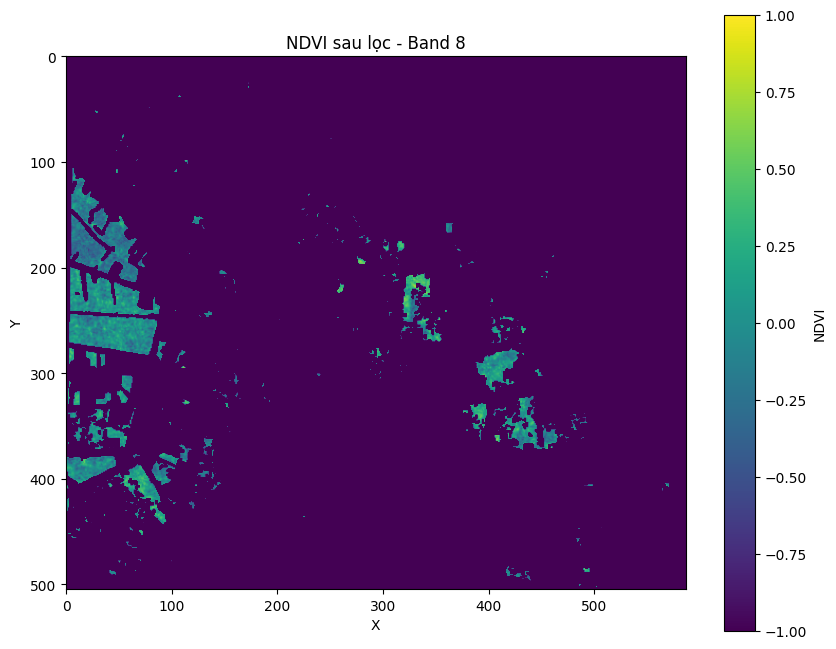

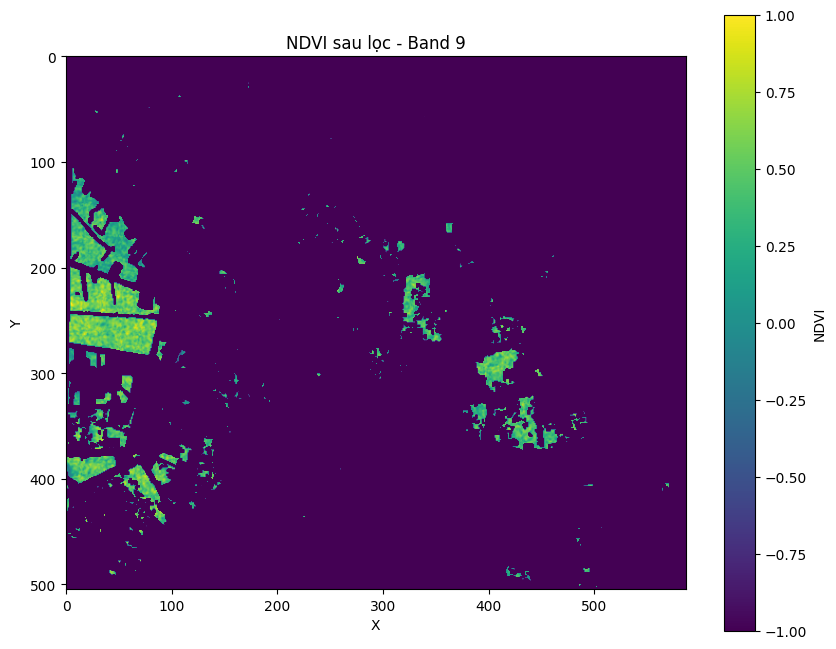

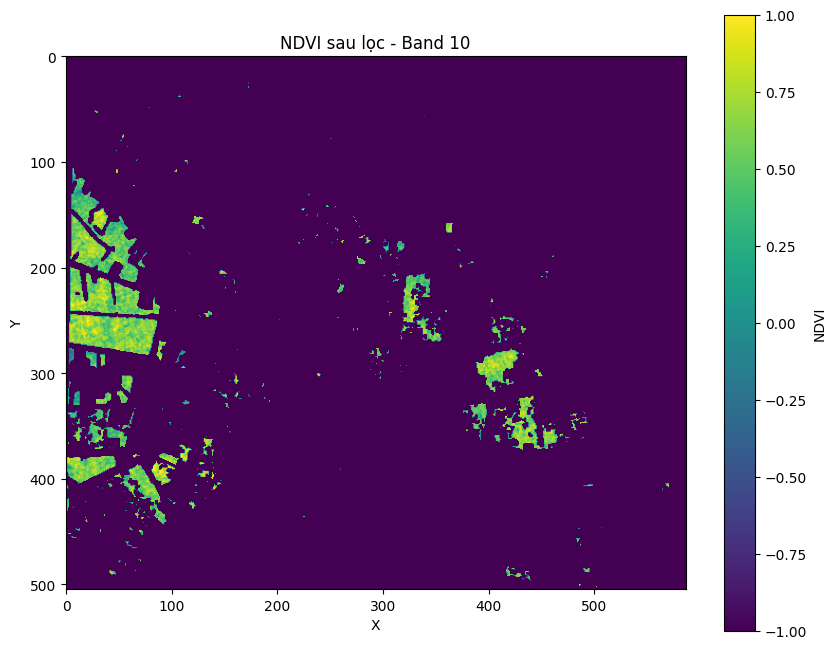

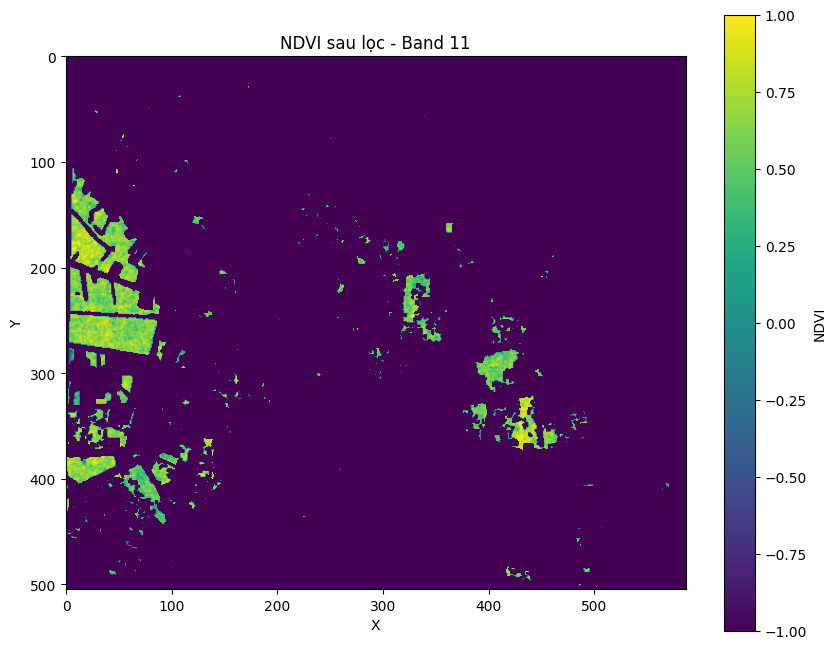

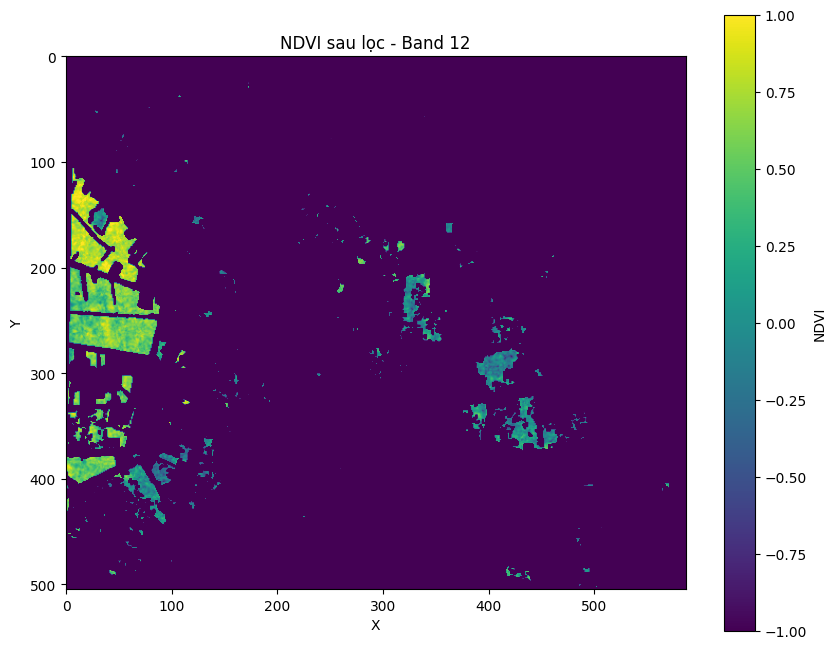

In [27]:
for i in range(13):
    ndvi_plot = ndvi_copy.sel(band=i+1)
    plt.figure(figsize=(10, 8))
    img = plt.imshow(ndvi_plot, vmin=-1, vmax=1)
    plt.title(f"NDVI sau lọc - Band {i}")
    plt.colorbar(img, label="NDVI")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.show()


In [3]:
saved_data = rioxarray.open_rasterio('output.tif')
saved_data

<xarray.DataArray (band: 13, y: 8874, x: 9902)> Size: 5GB
[1142314524 values with dtype=float32]
Coordinates:
  * band         (band) int64 104B 1 2 3 4 5 6 7 8 9 10 11 12 13
  * x            (x) float64 79kB 5.548e+05 5.548e+05 ... 6.538e+05 6.538e+05
  * y            (y) float64 71kB 1.106e+06 1.106e+06 ... 1.017e+06 1.017e+06
    spatial_ref  int64 8B 0
Attributes:
    long_name:                 NDVI
    AREA_OR_POINT:             Area
    STATISTICS_APPROXIMATE:    YES
    STATISTICS_MAXIMUM:        1.2841142416
    STATISTICS_MEAN:           -1.7747325438899
    STATISTICS_MINIMUM:        -2
    STATISTICS_STDDEV:         0.70756903350282
    STATISTICS_VALID_PERCENT:  100
    scale_factor:              1.0
    add_offset:                0.0

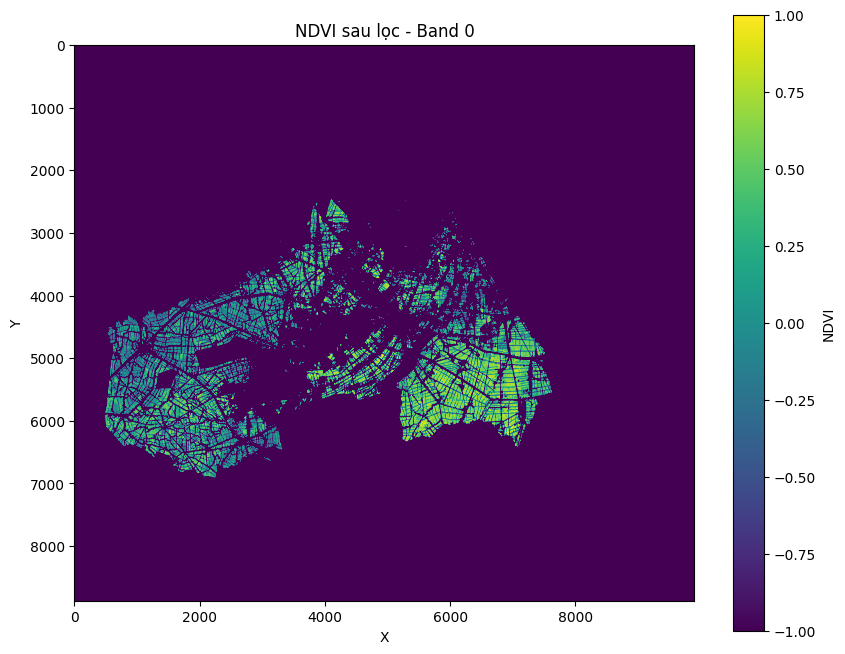

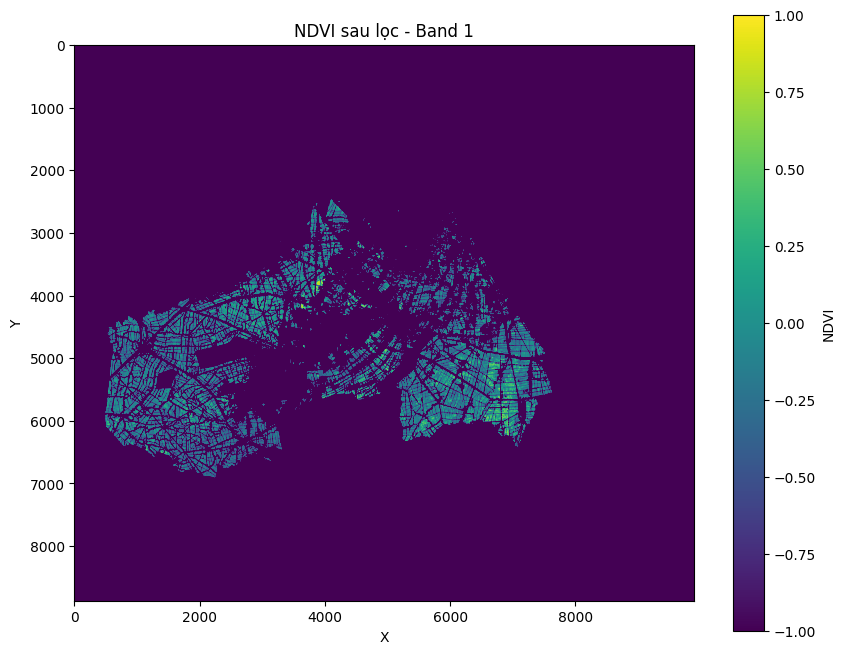

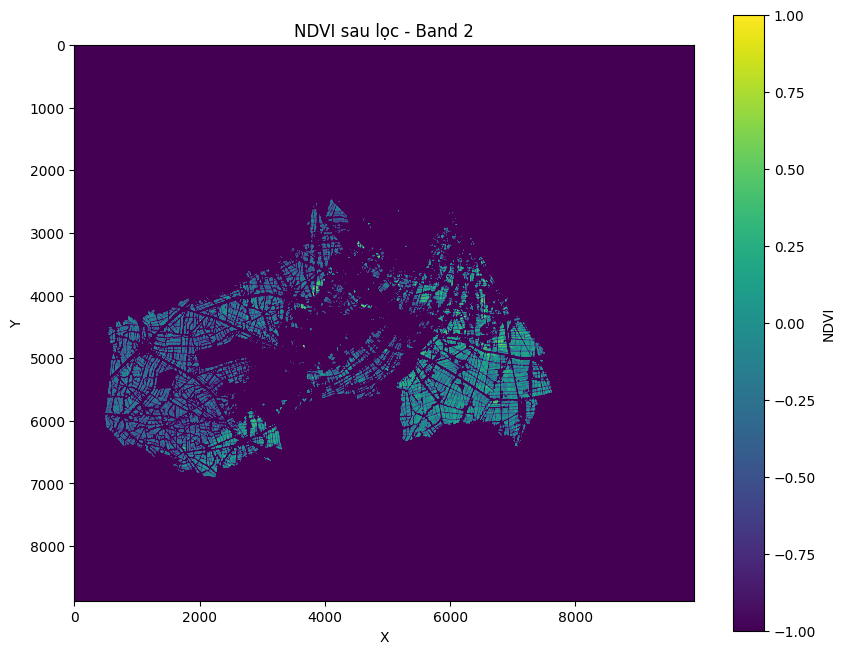

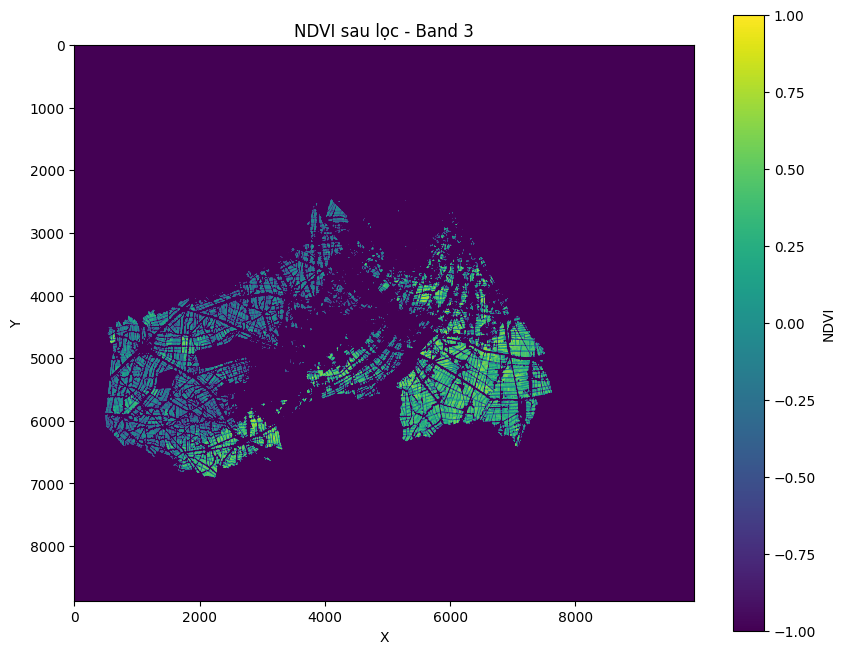

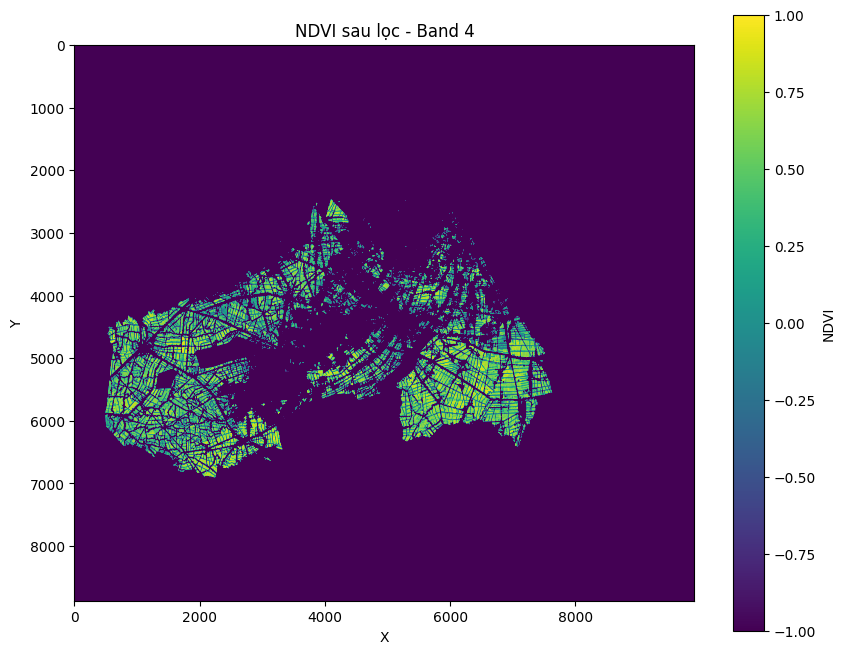

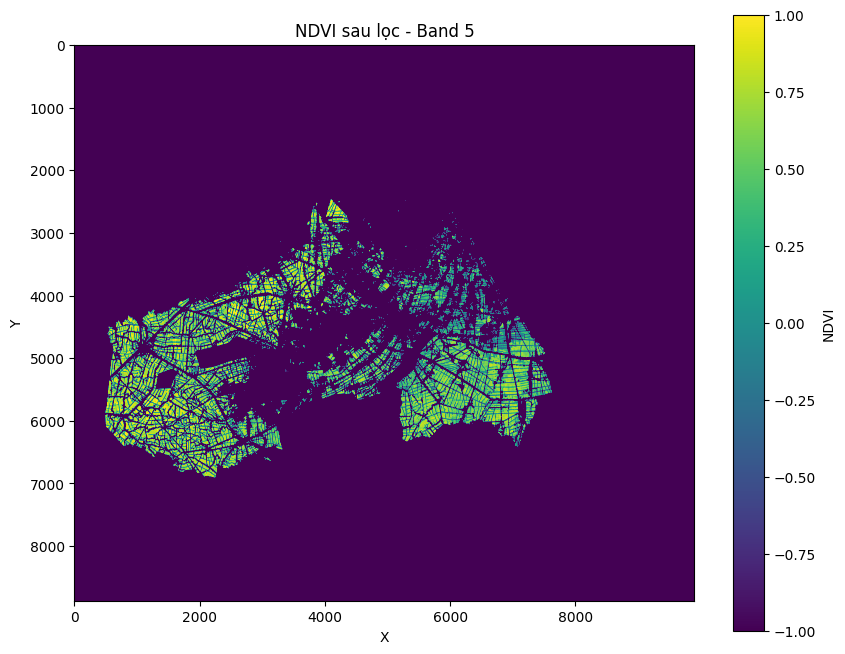

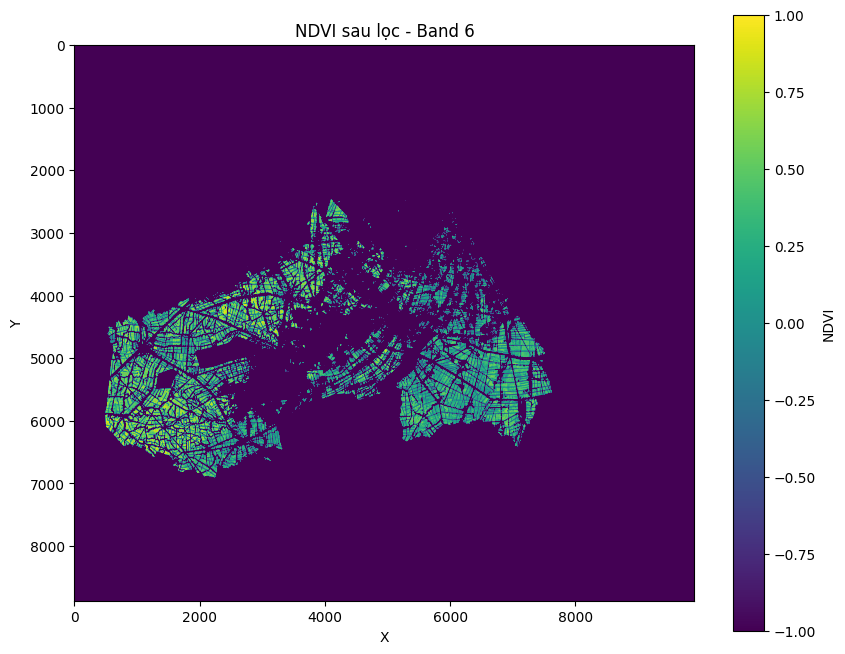

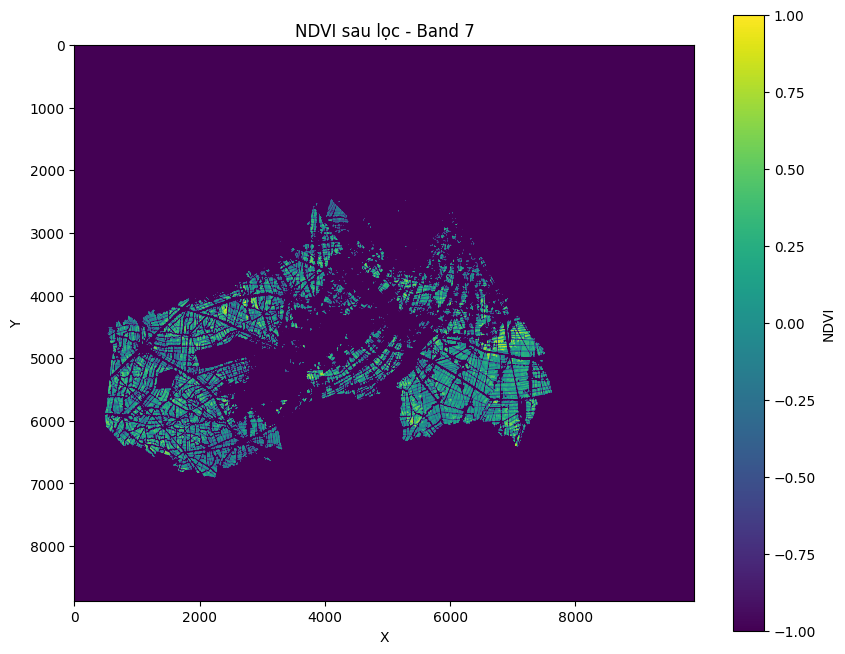

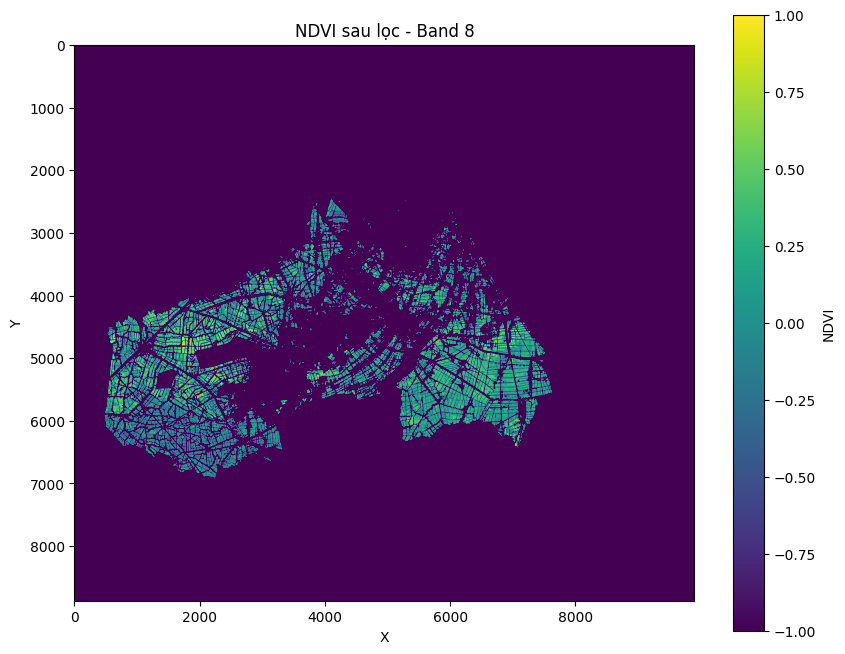

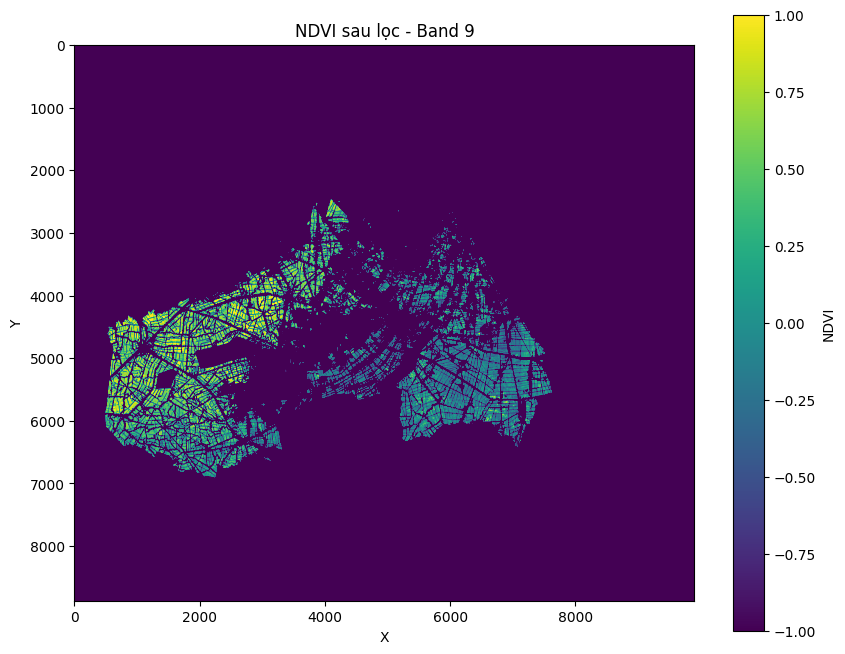

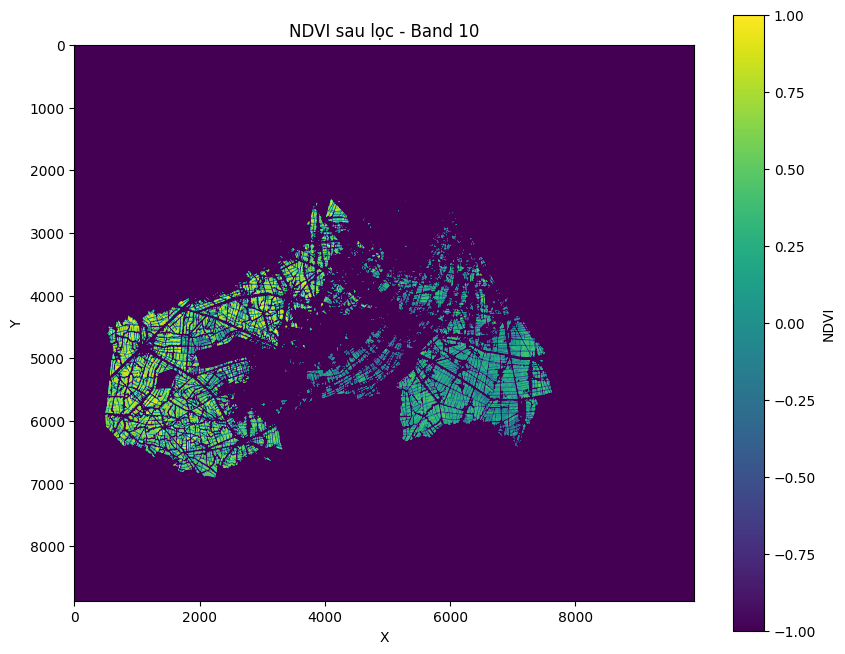

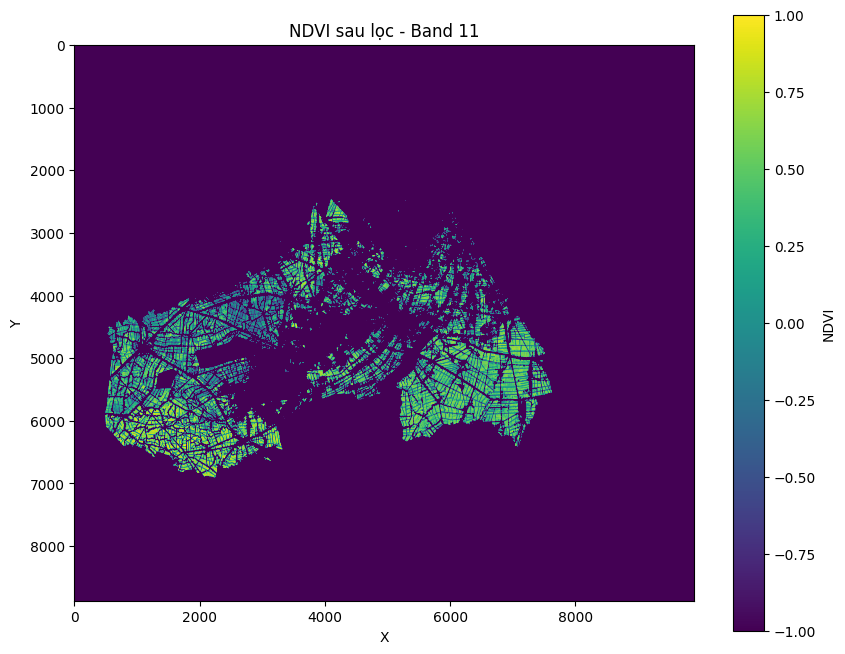

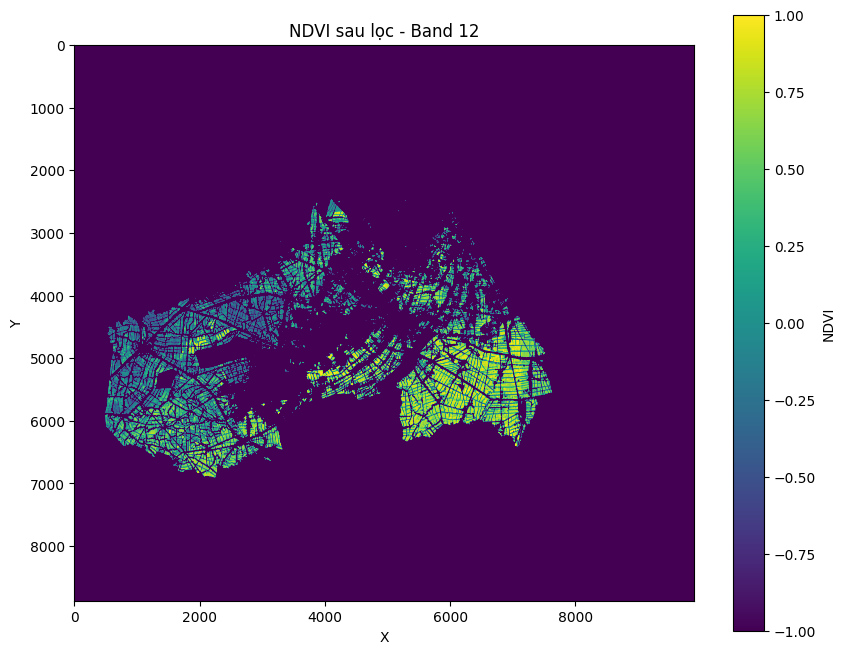

In [5]:
for i in range(13):
    draw_data = saved_data.sel(band=i+1)
    plt.figure(figsize=(10, 8))
    img = plt.imshow(draw_data, vmin=-1, vmax=1)
    plt.title(f"NDVI sau lọc - Band {i}")
    plt.colorbar(img, label="NDVI")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.show()